In [1]:
# Import libraries
import pandas as pd  # Data manipulation
import numpy as np  # Numerical computations
import matplotlib.pyplot as plt  # Static plots
import seaborn as sns  # Statistical plots
#import missingno as msno  # Missing data visualization

# Configuring Seaborn plot aesthetics
sns.set_theme(style='darkgrid', context='notebook')

import warnings
warnings.filterwarnings("ignore")

In [15]:
#Data Loads
sales = pd.read_csv('sales_details.csv')
product = pd.read_csv('prd_info.csv')
customer = pd.read_csv('cust_info.csv')
consumer = pd.read_csv('Consumer_Shopping_Trends_2026 (6).csv')

In [19]:
consumer.head(20)

,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level,gender,city_tier,shopping_preference
0,56,221111,6.5,12,0.7,1,6,16,16,28551,...,7,7,1,3,6,5,2,Other,Tier 3,Store
1,69,96029,8.2,13,2.7,6,9,14,1,124056,...,3,4,9,6,8,1,7,Male,Tier 3,Hybrid
2,46,19055,6.4,4,2.1,10,8,2,0,81939,...,4,10,1,1,3,3,3,Female,Tier 3,Store
3,32,53170,6.4,11,0.7,2,10,20,3,35901,...,10,2,4,8,2,6,6,Female,Tier 1,Store
4,60,244016,6.0,5,0.7,2,5,18,16,131971,...,2,5,8,9,7,1,6,Male,Tier 3,Store
5,25,114976,7.6,6,4.0,1,7,31,6,92423,...,10,6,6,3,4,4,8,Other,Tier 2,Store
6,78,43251,4.9,6,3.2,1,8,10,4,26398,...,2,8,9,4,9,9,8,Other,Tier 2,Hybrid
7,38,150604,3.1,10,3.7,4,9,17,7,131561,...,10,8,8,9,6,1,4,Other,Tier 2,Store
8,56,150996,7.3,2,1.1,5,3,28,0,123438,...,2,9,8,2,6,6,4,Female,Tier 3,Store
9,75,63037,6.8,4,2.9,4,8,2,9,74311,...,9,6,9,1,5,1,7,Female,Tier 3,Store


In [17]:
print(f"The number of rows is: {consumer.shape[0]} and the number of columns is: {consumer.shape[1]}")

The number of rows is: 11789 and the number of columns is: 25


In [18]:
consumer.columns

Index(['age', 'monthly_income', 'daily_internet_hours',
       'smartphone_usage_years', 'social_media_hours',
       'online_payment_trust_score', 'tech_savvy_score',
       'monthly_online_orders', 'monthly_store_visits', 'avg_online_spend',
       'avg_store_spend', 'discount_sensitivity', 'return_frequency',
       'avg_delivery_days', 'delivery_fee_sensitivity',
       'free_return_importance', 'product_availability_online',
       'impulse_buying_score', 'need_touch_feel_score', 'brand_loyalty_score',
       'environmental_awareness', 'time_pressure_level', 'gender', 'city_tier',
       'shopping_preference'],
      dtype='object')

In [20]:
consumer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11789 entries, 0 to 11788
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          11789 non-null  int64  
 1   monthly_income               11789 non-null  int64  
 2   daily_internet_hours         11789 non-null  float64
 3   smartphone_usage_years       11789 non-null  int64  
 4   social_media_hours           11789 non-null  float64
 5   online_payment_trust_score   11789 non-null  int64  
 6   tech_savvy_score             11789 non-null  int64  
 7   monthly_online_orders        11789 non-null  int64  
 8   monthly_store_visits         11789 non-null  int64  
 9   avg_online_spend             11789 non-null  int64  
 10  avg_store_spend              11789 non-null  int64  
 11  discount_sensitivity         11789 non-null  int64  
 12  return_frequency             11789 non-null  int64  
 13  avg_delivery_day

In [21]:
consumer.describe()

,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,return_frequency,avg_delivery_days,delivery_fee_sensitivity,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level
count,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,...,11789.00000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000
mean,48.729409,131704.282382,6.011367,7.597930,2.514471,5.498770,5.534312,24.677581,9.482144,74554.929341,...,4.46747,3.999661,5.468827,5.462041,5.518704,5.486386,5.485368,5.532021,5.448554,5.504114
std,17.899445,68120.726684,1.976811,4.011628,1.263047,2.880366,2.887251,14.431277,5.728825,43167.126595,...,2.88545,1.995881,2.870195,2.882177,2.867613,2.877918,2.877264,2.848796,2.872740,2.876561
min,18.000000,15005.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,523.000000,...,0.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,33.000000,72450.000000,4.600000,4.000000,1.600000,3.000000,3.000000,12.000000,5.000000,36797.000000,...,2.00000,2.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
50%,49.000000,131916.000000,6.000000,8.000000,2.500000,5.000000,6.000000,25.000000,9.000000,74859.000000,...,4.00000,4.000000,5.000000,5.000000,6.000000,5.000000,5.000000,6.000000,5.000000,6.000000
75%,64.000000,190505.000000,7.400000,11.000000,3.400000,8.000000,8.000000,37.000000,14.000000,112134.000000,...,7.00000,6.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000
max,79.000000,249989.000000,12.000000,14.000000,6.000000,10.000000,10.000000,49.000000,19.000000,149996.000000,...,9.00000,7.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


In [23]:
consumer.nunique()

age                               62
monthly_income                 11504
daily_internet_hours             111
smartphone_usage_years            14
social_media_hours                61
online_payment_trust_score        10
tech_savvy_score                  10
monthly_online_orders             50
monthly_store_visits              20
avg_online_spend               11347
avg_store_spend                11324
discount_sensitivity              10
return_frequency                  10
avg_delivery_days                  7
delivery_fee_sensitivity          10
free_return_importance            10
product_availability_online       10
impulse_buying_score              10
need_touch_feel_score             10
brand_loyalty_score               10
environmental_awareness           10
time_pressure_level               10
gender                             3
city_tier                          3
shopping_preference                3
dtype: int64

In [24]:
consumer.duplicated().sum()

np.int64(0)

<Axes: >

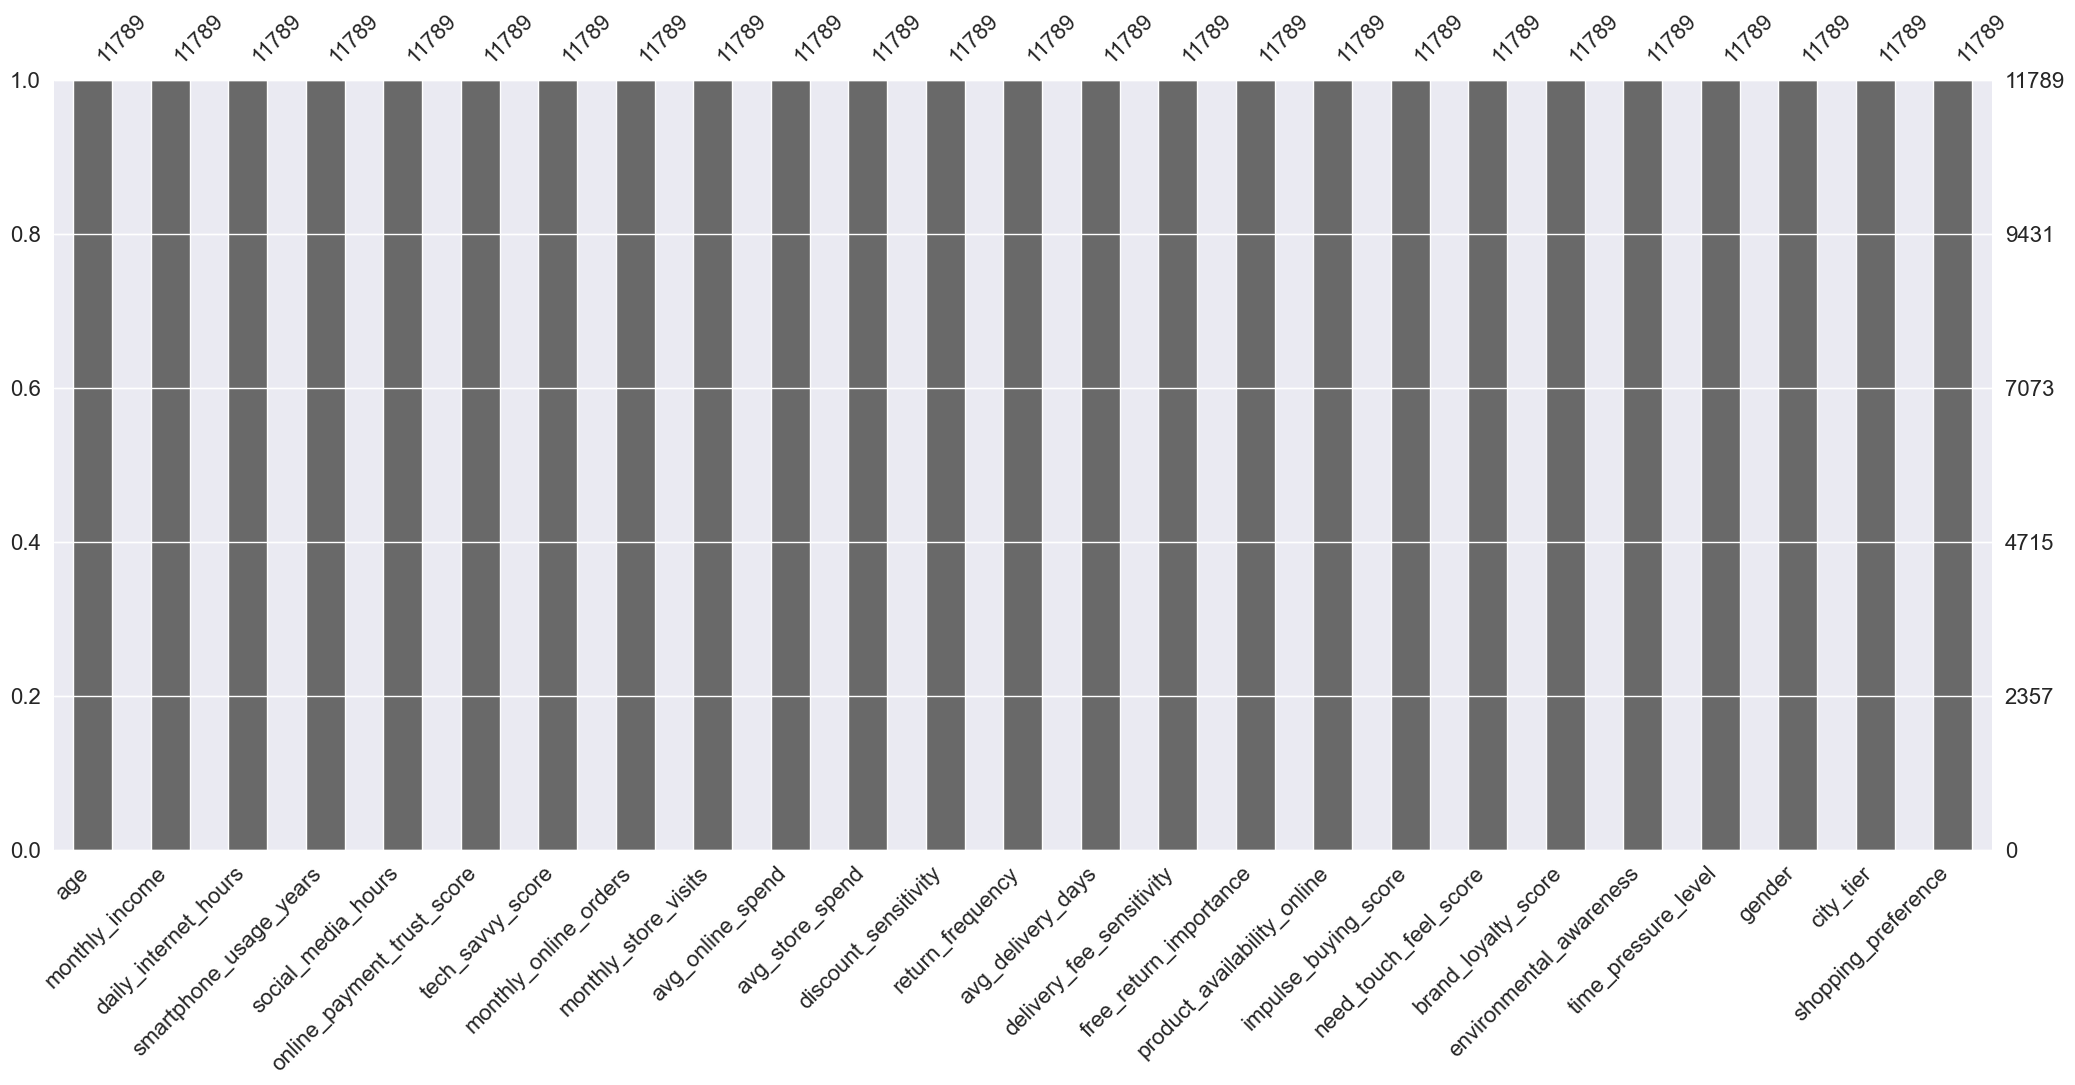

In [25]:
import missingno as msno
msno.bar(consumer)

In [26]:
# Count the number of missing values in each column
missing_values = consumer.isnull().sum().sort_values(ascending=False)
missing_percentage = (missing_values / len(consumer)) * 100
print(pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percentage}))

                             Missing Values  Percentage
age                                       0         0.0
monthly_income                            0         0.0
daily_internet_hours                      0         0.0
smartphone_usage_years                    0         0.0
social_media_hours                        0         0.0
online_payment_trust_score                0         0.0
tech_savvy_score                          0         0.0
monthly_online_orders                     0         0.0
monthly_store_visits                      0         0.0
avg_online_spend                          0         0.0
avg_store_spend                           0         0.0
discount_sensitivity                      0         0.0
return_frequency                          0         0.0
avg_delivery_days                         0         0.0
delivery_fee_sensitivity                  0         0.0
free_return_importance                    0         0.0
product_availability_online               0     

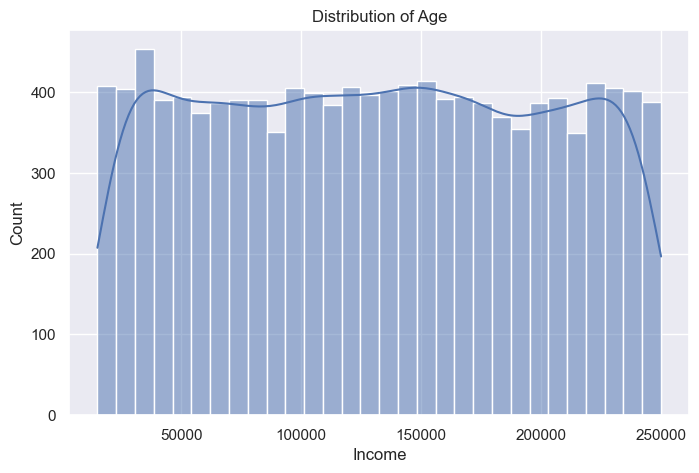

In [31]:
# Histogram for Age
plt.figure(figsize=(8, 5))
sns.histplot(consumer['monthly_income'].dropna(), bins=30, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Income')
plt.ylabel('Count')
plt.show()

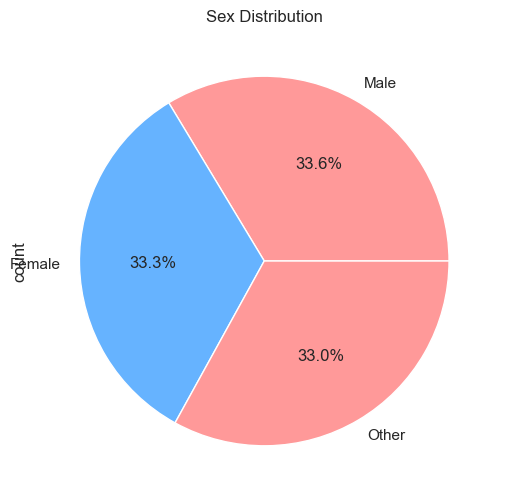

In [33]:
# Pie chart for Sex distribution
consumer['gender'].value_counts().plot.pie(autopct='%1.1f%%', figsize=(6, 6), colors=['#ff9999', '#66b3ff'])
plt.title('Sex Distribution')
plt.show()

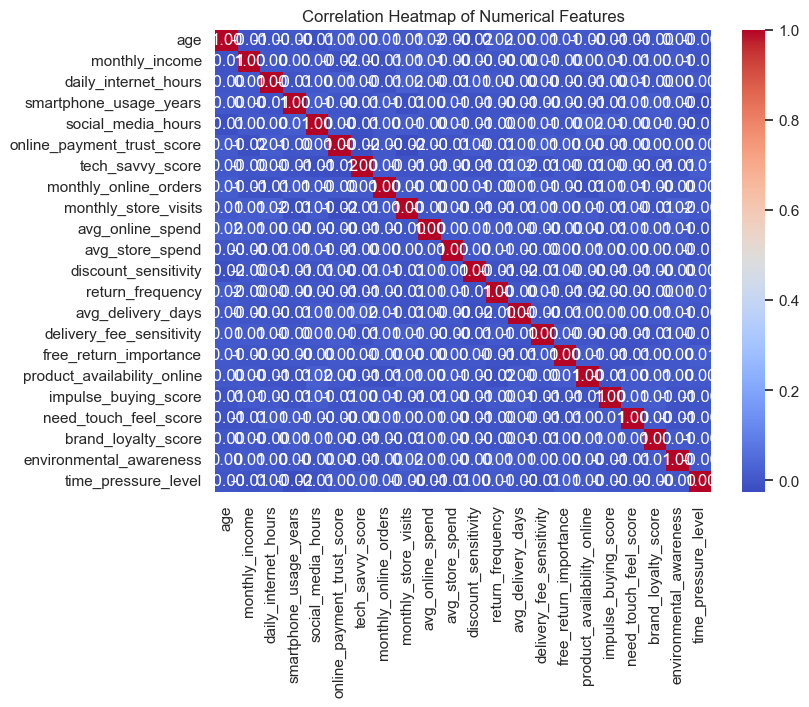

In [34]:
# Correlation heatmap for numerical columns only
plt.figure(figsize=(8, 6))
numerical_columns = consumer.select_dtypes(include=['int64', 'float64']).columns  # Select only numerical columns
sns.heatmap(consumer[numerical_columns].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

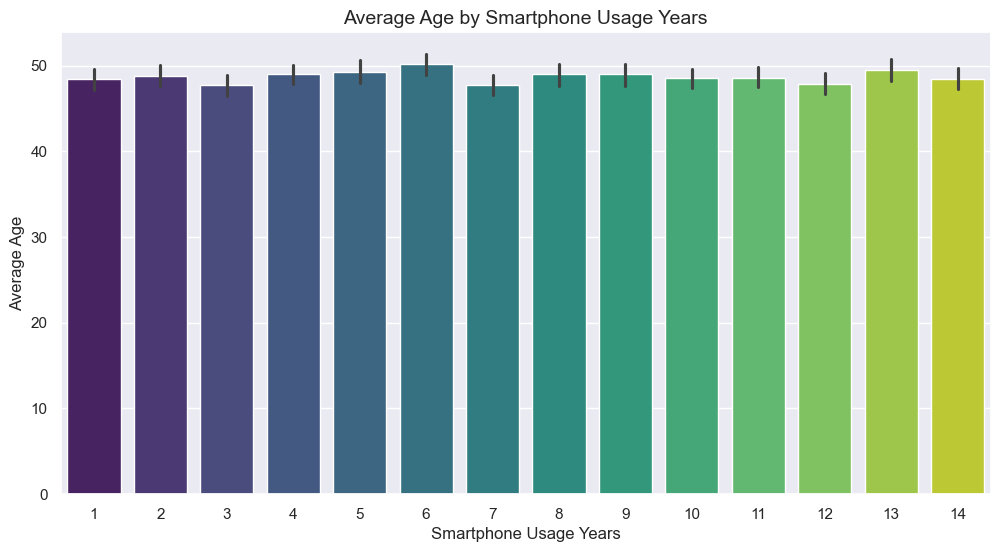

In [36]:
# Bar chart showing the average age for each amount of smartphone usage years
plt.figure(figsize=(12, 6))

# By default, seaborn barplots show the mean of the y-variable for each x-category
sns.barplot(data=consumer, x='smartphone_usage_years', y='age', palette='viridis')

plt.title('Average Age by Smartphone Usage Years', fontsize=14)
plt.xlabel('Smartphone Usage Years', fontsize=12)
plt.ylabel('Average Age', fontsize=12)
plt.show()
